In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, QuantileTransformer, PowerTransformer
from sklearn import set_config
set_config(transform_output = "pandas")
from sklearn.cluster import KMeans

In [61]:
# Read the CSV file
df_5 = pd.read_csv('/Users/samaardi/Desktop/WBS-Data Science Bootcamp/unsupervised machine learning/3_spotify_5000_songs.csv')

In [62]:
df_5.sample(20)

,Unnamed: 0,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,duration_ms,time_signature,id,html
2390,2390,"La Cenerentola / Act 2: ""Non più mesta"" ...",Gioachino Rossini,0.450,0.261,4,-16.633,1,0.0797,0.980000,0.000965,0.0694,0.2960,136.941,,189196,4,2VeWXYKHiESWNipFu33QGv,https://open.spotify.com/track/2VeWXYKHiESWNip...
248,248,Cafe de flore ...,Doctor Rockit,0.696,0.648,1,-8.381,0,0.0419,0.594000,0.832000,0.2840,0.5610,104.015,,507813,4,2yuiqP0DwTOXB8lOibssms,https://open.spotify.com/track/2yuiqP0DwTOXB8l...
3216,3216,En La Cama (feat. Daddy Yankee) ...,Nicky Jam,0.855,0.912,10,-4.832,0,0.1450,0.183000,0.000000,0.1220,0.8850,104.072,,157023,4,2Eg6dOam7cAe5turf2bnCg,https://open.spotify.com/track/2Eg6dOam7cAe5tu...
1581,1581,Don't Cha ...,The Pussycat Dolls,0.875,0.631,1,-3.475,1,0.0990,0.005420,0.000003,0.1270,0.5490,120.002,,272080,4,24kGngQeXHt0uhffKpq0zj,https://open.spotify.com/track/24kGngQeXHt0uhf...
3070,3070,Teenage Crime - Radio Edit ...,Adrian Lux,0.647,0.843,2,-4.801,1,0.0364,0.019200,0.686000,0.1040,0.3280,128.015,,168920,4,61zjO4oHZ36Qi4D4rsL0TD,https://open.spotify.com/track/61zjO4oHZ36Qi4D...
1840,1840,Air on a G String ...,Johann Sebastian Bach,0.109,0.314,2,-11.270,1,0.0390,0.982000,0.895000,0.1080,0.0557,172.773,,289640,3,0mD1a7haZKdX9I0oPywrMb,https://open.spotify.com/track/0mD1a7haZKdX9I0...
381,381,Nosebleed ...,Deerhunter,0.322,0.885,9,-5.167,1,0.0534,0.000005,0.000099,0.1130,0.6340,153.167,,172760,4,3lXbRMh6mBAppRX3UabXbW,https://open.spotify.com/track/3lXbRMh6mBAppRX...
1619,1619,If We Ever Meet Again (Featuring Katy Perry) ...,Timbaland,0.652,0.605,8,-7.371,1,0.0393,0.004810,0.000000,0.0605,0.3940,126.091,,292707,4,360UM2DaiHZPRu0EsrOvMp,https://open.spotify.com/track/360UM2DaiHZPRu0...
4630,4630,Rock with you ...,SEVENTEEN,0.621,0.816,11,-5.242,1,0.1040,0.096600,0.000000,0.1340,0.6940,163.966,,180360,4,6LnEoRQKMcaFTR5UvaKuBy,https://open.spotify.com/track/6LnEoRQKMcaFTR5...
4712,4712,Das alles ändert nichts daran - Radio Version ...,Maya Saban,0.546,0.722,2,-5.751,0,0.0438,0.484000,0.000000,0.0974,0.2900,139.953,,230040,4,2s3kQZo5diMGGe7Vi9ZXEd,https://open.spotify.com/track/2s3kQZo5diMGGe7...


In [63]:
df_5.columns = df_5.columns.str.strip()

In [64]:
df_5.columns

Index(['Unnamed: 0', 'name', 'artist', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'type', 'duration_ms', 'time_signature',
       'id', 'html'],
      dtype='object')

In [65]:
df_5.drop(columns=['Unnamed: 0', 'type', 'duration_ms', 'id', 'html'], inplace=True)

In [66]:
df_5.set_index(['name', 'artist'], inplace=True)

In [67]:
minmax_scaler = MinMaxScaler()
# we fit and transform our data to minmax scaler to see the correlation after eliminating some columns
df_5_scaled = minmax_scaler.fit_transform(df_5)

In [68]:
df_5_scaled

,,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
name,artist,,,,,,,,,,,,
Se Eu Quiser Falar Com Deus,Gilberto Gil,0.680455,0.25900,1.000000,0.763897,0.0,0.076797,0.696787,0.000060,0.987842,0.310660,0.515800,0.8
Saudade De Bahia,Antônio Carlos Jobim,0.767322,0.39900,0.181818,0.771967,1.0,0.037691,0.217871,0.000002,0.108409,0.703553,0.584322,0.8
"Canta Canta, Minha Gente",Martinho Da Vila,0.880041,0.73000,0.181818,0.798018,1.0,0.377996,0.454819,0.000064,0.125633,0.918782,0.437862,0.8
Mulher Eu Sei,Chico César,0.729059,0.05020,0.363636,0.682811,1.0,0.051307,0.882530,0.000041,0.391084,0.531980,0.499098,0.8
Rosa Morena,Kurt Elling,0.673216,0.11900,0.545455,0.655228,1.0,0.041394,0.919679,0.000348,0.105370,0.408122,0.565171,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",Pyotr Ilyich Tchaikovsky,0.208893,0.06940,0.272727,0.596818,1.0,0.051525,0.920683,0.725888,0.084296,0.066497,0.410795,0.8
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",Tristan Murail,0.194416,0.10100,0.545455,0.621548,1.0,0.048148,0.858434,0.432487,0.070314,0.036041,0.388495,0.8
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",Arnold Schoenberg,0.061634,0.00093,0.818182,0.277803,1.0,0.047277,0.954819,0.983756,0.078217,0.034924,0.334469,0.6


In [190]:
seed = 42
max_k = 100
inertia_list=[]

for i in range(10, max_k + 1):
  df_5_kmean = KMeans(n_clusters= i,
                      n_init = "auto",
                    random_state= seed
                    )
  df_5_kmean.fit(df_5_scaled_without_inst_mode_key)
  inertia_list.append(df_5_kmean.inertia_)

/Users/samaardi/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


()

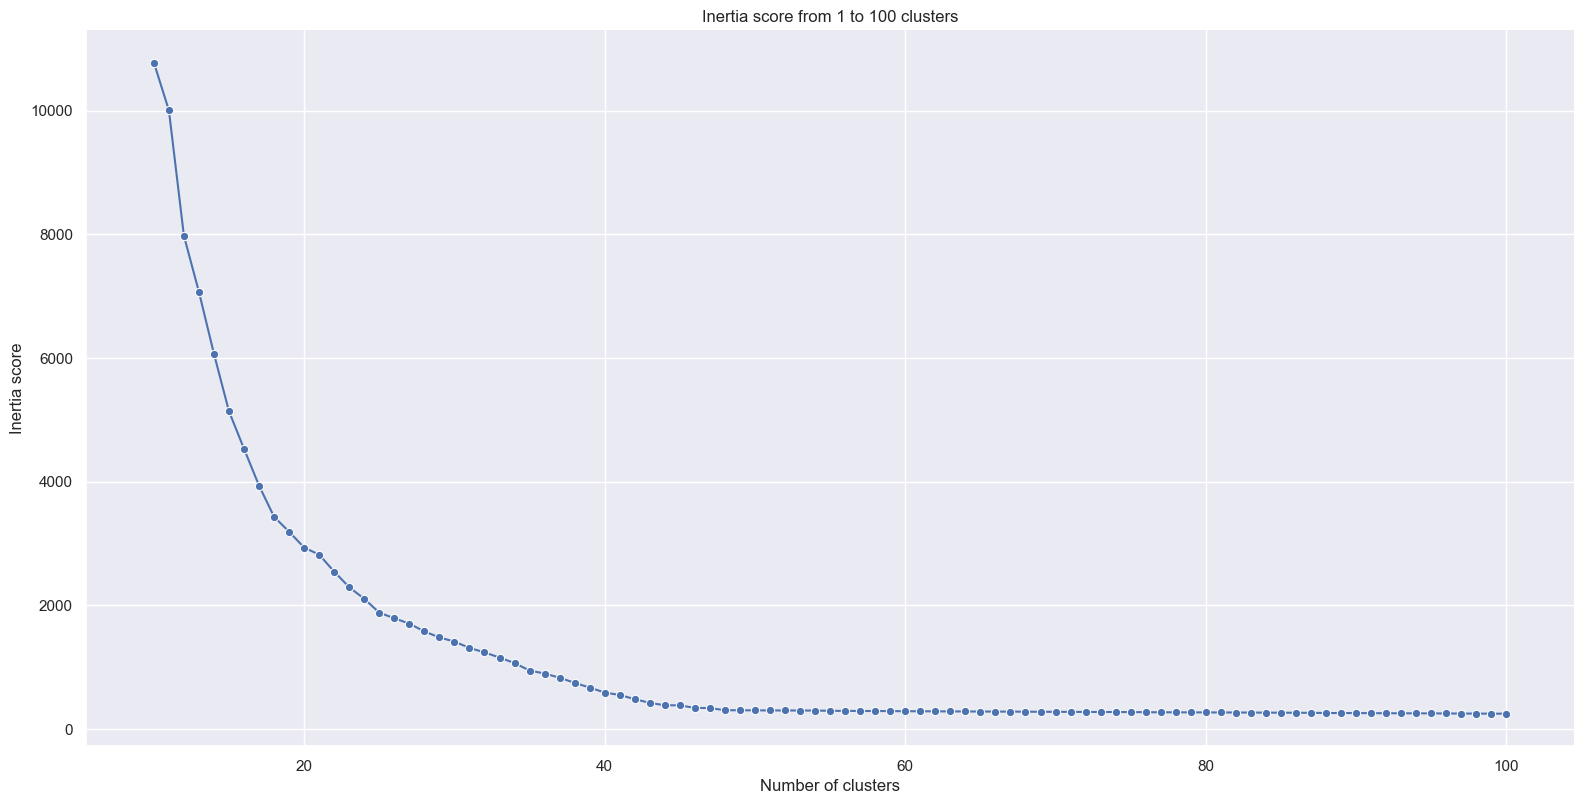

In [191]:
# Set the Seaborn theme to darkgrid
sns.set_theme(style='darkgrid')
%matplotlib inline
(
# Create a line plot of the inertia scores
sns.relplot(y = inertia_list,
            x = range(10, max_k + 1),
            kind = 'line',
            marker = 'o',
            height = 8,
            aspect = 2)
# Set the title of the plot
.set(title=f"Inertia score from 1 to {max_k} clusters")
# Set the axis labels
.set_axis_labels("Number of clusters", "Inertia score")
);()

In [11]:
from sklearn.metrics import silhouette_score

In [189]:
max_k = 100
sil_list = []
for j in range(10, max_k + 1):
  s_kmeans = KMeans(n_clusters=j,
             n_init = "auto",
             random_state=seed)
  s_kmeans.fit(df_5_scaled_without_inst_mode_key)
  labels = s_kmeans.labels_
  score = silhouette_score(df_5_scaled_without_inst_mode_key, labels)
  sil_list.append(score)

/Users/samaardi/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


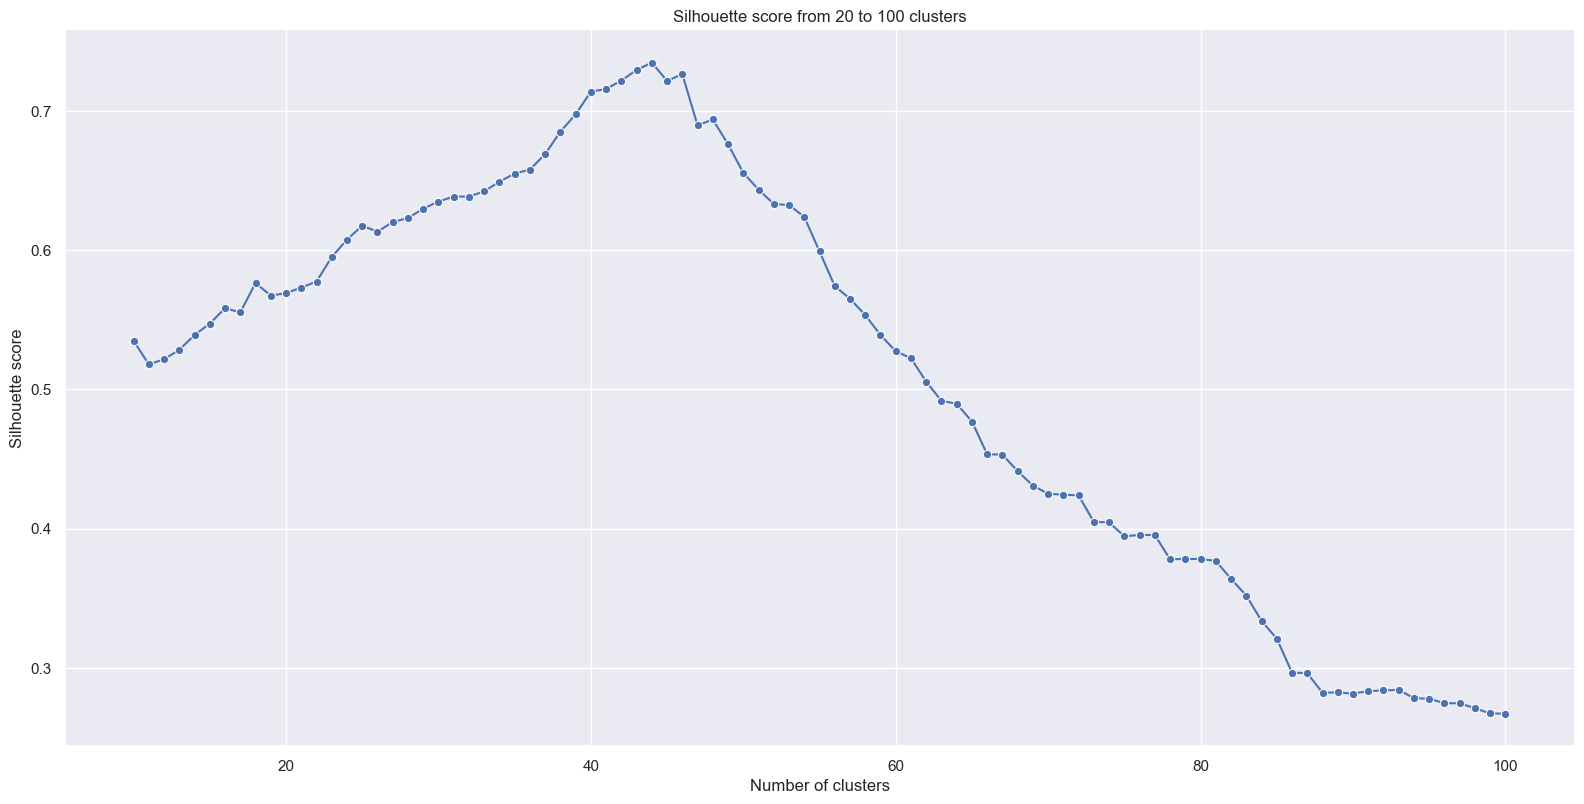

In [192]:
(
sns.relplot(y = sil_list,
            x = range(10, max_k + 1),
            kind = 'line',
            marker = 'o',
            height = 8,
            aspect = 2)
.set(title=f"Silhouette score from 20 to {max_k } clusters")
.set_axis_labels("Number of clusters", "Silhouette score")
);

In [16]:
from sklearn.decomposition import PCA

In [115]:
df_5_scaled_without_inst = df_5_scaled.drop(columns=['instrumentalness']).copy()

In [120]:
df_5_scaled_without_inst

,,danceability,energy,key,loudness,mode,speechiness,acousticness,liveness,valence,tempo,time_signature
name,artist,,,,,,,,,,,
Se Eu Quiser Falar Com Deus,Gilberto Gil,0.680455,0.25900,1.000000,0.763897,0.0,0.076797,0.696787,0.987842,0.310660,0.515800,0.8
Saudade De Bahia,Antônio Carlos Jobim,0.767322,0.39900,0.181818,0.771967,1.0,0.037691,0.217871,0.108409,0.703553,0.584322,0.8
"Canta Canta, Minha Gente",Martinho Da Vila,0.880041,0.73000,0.181818,0.798018,1.0,0.377996,0.454819,0.125633,0.918782,0.437862,0.8
Mulher Eu Sei,Chico César,0.729059,0.05020,0.363636,0.682811,1.0,0.051307,0.882530,0.391084,0.531980,0.499098,0.8
Rosa Morena,Kurt Elling,0.673216,0.11900,0.545455,0.655228,1.0,0.041394,0.919679,0.105370,0.408122,0.565171,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",Pyotr Ilyich Tchaikovsky,0.208893,0.06940,0.272727,0.596818,1.0,0.051525,0.920683,0.084296,0.066497,0.410795,0.8
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",Tristan Murail,0.194416,0.10100,0.545455,0.621548,1.0,0.048148,0.858434,0.070314,0.036041,0.388495,0.8
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",Arnold Schoenberg,0.061634,0.00093,0.818182,0.277803,1.0,0.047277,0.954819,0.078217,0.034924,0.334469,0.6


In [140]:
df_5_scaled_without_inst_mode = df_5_scaled.drop(columns=['instrumentalness', 'mode']).copy()

In [164]:
df_5_scaled_without_inst_mode_key = df_5_scaled.drop(columns=['instrumentalness', 'mode', 'key']).copy()

In [213]:
my_pca = PCA()

In [214]:
my_pca = PCA()
pca_variance_df = my_pca.fit(df_filtered)

In [215]:
my_pca = PCA()
pca_variance_df = my_pca.fit(df_filtered)
explained_blobs_variance_array = my_pca.explained_variance_ratio_
explained_blobs_variance_array

In [216]:
explained_blobs_variance_array

array([0.51636969, 0.26349369, 0.06080892, 0.05194887, 0.03942834,
       0.03278918, 0.01584041, 0.01316197, 0.00615893])

In [87]:
import numpy as np

/Users/samaardi/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


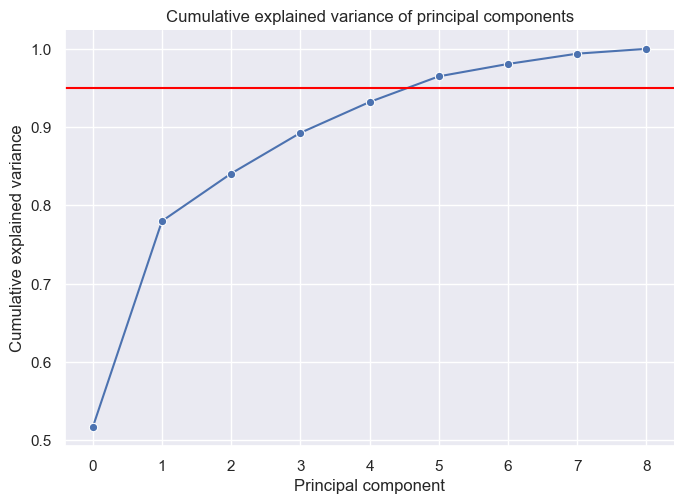

In [218]:
(
  # Create a cumulative explained variance plot
  sns.relplot(
      kind = "line",  # Create a line plot
      x = np.arange(len(explained_blobs_variance_array)),  # Set the x-axis to be the principal component index
      y = np.cumsum(explained_blobs_variance_array),  # Set the y-axis to be the cumulative explained variance
      marker = "o",  # Use a circle marker for the data points
      aspect = 1.4,  # Set the aspect ratio of the plot to be 1.4
  )
  # Set the title of the plot
  .set(title = "Cumulative explained variance of principal components")
  # Set the axis labels
  .set_axis_labels("Principal component", "Cumulative explained variance")
);

# Add a horizontal red line at 0.95 on the y axis
plt.axhline(y = 0.95,
            color = 'red');

In [219]:
# Calculate the cumulative sum
cumulative_sum = np.cumsum(explained_blobs_variance_array)

# Find the index where the cumulative sum reaches 0.95
index = np.searchsorted(cumulative_sum, 0.95)

# Print the number of components required to reach 0.95 variance
print(index + 1)

6


In [230]:
my_pca = PCA(n_components=6)
my_t = my_pca.fit_transform(df_filtered)
my_t

In [231]:
my_t

,,pca0,pca1,pca2,pca3,pca4,pca5
name,artist,,,,,,
Se Eu Quiser Falar Com Deus,Gilberto Gil,0.520374,0.085064,0.444548,0.701886,0.160809,0.119738
Saudade De Bahia,Antônio Carlos Jobim,0.032889,0.361663,-0.169218,0.003874,0.082591,0.193315
"Canta Canta, Minha Gente",Martinho Da Vila,-0.049847,0.582914,0.007823,-0.003400,-0.143568,-0.161432
Mulher Eu Sei,Chico César,0.780760,0.363739,0.073912,0.252233,0.076932,0.101656
Rosa Morena,Kurt Elling,0.812833,0.238830,-0.095575,0.036292,0.102037,-0.027820
...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",Pyotr Ilyich Tchaikovsky,0.981535,-0.290250,-0.069635,-0.034171,-0.081627,0.078097
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",Tristan Murail,0.921521,-0.336591,-0.097442,-0.030291,-0.101689,0.080095
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",Arnold Schoenberg,1.141075,-0.406265,-0.048685,-0.092648,-0.182110,0.241228


In [109]:
!pip install ydata_profiling

In [110]:
from ydata_profiling import ProfileReport

In [111]:
ProfileReport(df_5_scaled)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [232]:
kmean_best_pca = KMeans(n_clusters=46,
      n_init='auto',
      random_state=seed)
fitted_best_kmean = kmean_best_pca.fit(my_t)

In [233]:
kmean_best_pca = KMeans(n_clusters=46,
      n_init='auto',
      random_state=seed)
fitted_best_kmean = kmean_best_pca.fit(my_t)
fitted_best_kmean.labels_
my_t['cluster'] = fitted_best_kmean.labels_
sns.scatterplot(data=my_t,x=my_t['pca0'],y=my_t['pca1'], hue=my_t['cluster'])

array([29, 24,  5, ...,  0,  0, 15], dtype=int32)

In [234]:
my_t['cluster'] = fitted_best_kmean.labels_

<Axes: xlabel='pca0', ylabel='pca1'>

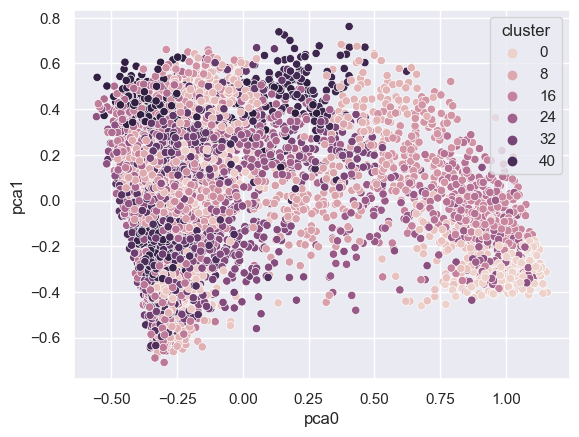

In [235]:
sns.scatterplot(data=my_t,x=my_t['pca0'],y=my_t['pca1'], hue=my_t['cluster'])

In [204]:
df_filtered = df_5_scaled_without_inst_mode_key.loc[~(df_5_scaled_without_inst_mode_key == 0).all(axis=1)]


In [236]:
df_filtered['cluster'] = fitted_best_kmean.labels_

/tmp/ipykernel_12190/2738563621.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['cluster'] = fitted_best_kmean.labels_


In [238]:
df_filtered.shape

(5234, 10)

In [240]:
df_filtered.loc[df_filtered['cluster'] == 0, :].sample(20)

,,danceability,energy,loudness,speechiness,acousticness,liveness,valence,tempo,time_signature,cluster
name,artist,,,,,,,,,,
Jacob and the Stone,Emile Mosseri,0.199586,0.17100,0.676633,0.040087,0.918675,0.120567,0.106599,0.392855,0.8,0
"Symphony No. 3, Op. 36: I. Lento - Sostenuto Tranquillo Ma Cantabile",Henryk Górecki,0.086867,0.12400,0.660331,0.041612,0.554217,0.199595,0.033604,0.394481,0.8,0
"Piano Sonata No. 13 in A Major, D. 664: II. Andante",Franz Schubert,0.381593,0.00245,0.405399,0.052397,0.998996,0.072746,0.074721,0.451484,0.2,0
Dagdraumur,Eydís Evensen,0.290589,0.04450,0.580190,0.068519,0.968876,0.104357,0.086396,0.340165,0.8,0
Yanagiwara,Hirotaka Shirotsubaki,0.133402,0.07070,0.574566,0.045969,0.924699,0.098886,0.028731,0.349395,0.8,0
"Giordano: Andrea Chénier, Act 3: ""La mamma morta"" (Maddalena)",Umberto Giordano,0.225440,0.13400,0.766115,0.047821,0.972892,0.089564,0.039391,0.420758,0.8,0
"2 Stücke, Op. 16: I. Romanze (Quasi adagio)",Leone Sinigaglia,0.189245,0.03120,0.608653,0.045316,0.992972,0.084904,0.097360,0.370485,0.8,0
"Serenade For Strings In E, Op.22, B. 52: 1. Moderato",Antonín Dvořák,0.137539,0.02080,0.498142,0.045643,0.886546,0.112462,0.060000,0.313608,0.8,0
Lizard Point - Remastered 2004,Brian Eno,0.140641,0.01080,0.391999,0.037364,0.900602,0.148936,0.031675,0.413706,0.8,0


In [241]:
df_filtered.loc[df_filtered['cluster'] == 10, :].sample(20)

,,danceability,energy,loudness,speechiness,acousticness,liveness,valence,tempo,time_signature,cluster
name,artist,,,,,,,,,,
This Is A Move - Live,Tasha Cobbs Leonard,0.253361,0.723,0.897379,0.068192,0.411647,0.256332,0.363452,0.438609,0.8,10
Ask For Rain,Gene Moore,0.331954,0.486,0.837452,0.040087,0.630522,0.356636,0.272081,0.568844,0.8,10
In My Blood / Swan Lake,The Piano Guys,0.341262,0.528,0.824688,0.035076,0.877510,0.305978,0.297462,0.653848,0.8,10
River Deep - Mountain High,Ike & Tina Turner,0.402275,0.745,0.864041,0.041830,0.780120,0.144883,0.275127,0.388041,0.8,10
Wonderful! Wonderful! (with Ray Conniff & His Orchestra & Chorus) - Single Version,Johnny Mathis,0.258532,0.398,0.823335,0.032789,0.744980,0.098784,0.567513,0.678434,0.8,10
Espinàs,Vàlius,0.274043,0.811,0.906410,0.058932,0.662651,0.216819,0.502538,0.746269,0.8,10
"A Love Supreme, Pt. II - Resolution",John Coltrane,0.352637,0.570,0.787226,0.073312,0.583333,0.097872,0.397970,0.419431,0.8,10
110,Capital Bra,0.496381,0.749,0.895683,0.470588,0.535141,0.101013,0.425381,0.836749,0.8,10
Layla,Derek & The Dominos,0.417787,0.902,0.914871,0.072440,0.579317,0.290780,0.504569,0.540535,0.8,10


In [243]:
df_filtered.drop(columns=['cluster'], inplace=True)

KeyError: "['cluster'] not found in axis"

In [248]:
my_dv = PCA(n_components=1)
dance_val = my_dv.fit_transform(df_filtered[['danceability', 'valence']])
dance_val

,,pca0
name,artist,
Se Eu Quiser Falar Com Deus,Gilberto Gil,-0.023528
Saudade De Bahia,Antônio Carlos Jobim,0.345892
"Canta Canta, Minha Gente",Martinho Da Vila,0.586381
Mulher Eu Sei,Chico César,0.184377
Rosa Morena,Kurt Elling,0.051264
...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",Pyotr Ilyich Tchaikovsky,-0.497485
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",Tristan Murail,-0.530654
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",Arnold Schoenberg,-0.609269


In [249]:
my_dv_2 = PCA(n_components=1)
loud_energy_acc = my_dv_2.fit_transform(df_filtered[['loudness', 'energy', 'acousticness']])
loud_energy_acc

,,pca0
name,artist,
Se Eu Quiser Falar Com Deus,Gilberto Gil,0.564666
Saudade De Bahia,Antônio Carlos Jobim,0.106960
"Canta Canta, Minha Gente",Martinho Da Vila,0.085583
Mulher Eu Sei,Chico César,0.849591
Rosa Morena,Kurt Elling,0.841602
...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",Pyotr Ilyich Tchaikovsky,0.882772
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",Tristan Murail,0.810967
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",Arnold Schoenberg,1.007201


In [252]:
df_filtered['danceability_valence'] = dance_val

/tmp/ipykernel_12190/1798411962.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['danceability_valence'] = dance_val


In [250]:
df_filtered['acoustic_loudness_energy'] = loud_energy_acc

/tmp/ipykernel_12190/4133803689.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['acoustic_loudness_energy'] = loud_energy_acc


In [254]:
df_filtered.drop(columns=['danceability', 'valence', 'energy', 'acousticness', 'loudness'], inplace=True)

/tmp/ipykernel_12190/2457703881.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.drop(columns=['danceability', 'valence', 'energy', 'acousticness', 'loudness'], inplace=True)


In [255]:
df_filtered

,,speechiness,liveness,tempo,time_signature,acoustic_loudness_energy,danceability_valence
name,artist,,,,,,
Se Eu Quiser Falar Com Deus,Gilberto Gil,0.076797,0.987842,0.515800,0.8,0.564666,-0.023528
Saudade De Bahia,Antônio Carlos Jobim,0.037691,0.108409,0.584322,0.8,0.106960,0.345892
"Canta Canta, Minha Gente",Martinho Da Vila,0.377996,0.125633,0.437862,0.8,0.085583,0.586381
Mulher Eu Sei,Chico César,0.051307,0.391084,0.499098,0.8,0.849591,0.184377
Rosa Morena,Kurt Elling,0.041394,0.105370,0.565171,0.8,0.841602,0.051264
...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",Pyotr Ilyich Tchaikovsky,0.051525,0.084296,0.410795,0.8,0.882772,-0.497485
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",Tristan Murail,0.048148,0.070314,0.388495,0.8,0.810967,-0.530654
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",Arnold Schoenberg,0.047277,0.078217,0.334469,0.6,1.007201,-0.609269


In [256]:
df_filtered.columns

Index(['speechiness', 'liveness', 'tempo', 'time_signature',
       'acoustic_loudness_energy', 'danceability_valence'],
      dtype='object')

In [ ]:
my_pca = PCA(n_components=4)
my_t = my_pca.fit_transform(df_filtered)
my_t

In [302]:
my_t

,,pca0,pca1,pca2,pca3,cluster
name,artist,,,,,
Se Eu Quiser Falar Com Deus,Gilberto Gil,0.517147,0.078617,0.828459,-0.021070,28
Saudade De Bahia,Antônio Carlos Jobim,0.031652,0.364625,-0.067785,0.032777,31
"Canta Canta, Minha Gente",Martinho Da Vila,-0.049687,0.586627,-0.041842,-0.118727,6
Mulher Eu Sei,Chico César,0.779008,0.361657,0.251758,-0.009553,20
Rosa Morena,Kurt Elling,0.810276,0.238812,-0.035169,0.063772,20
...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",Pyotr Ilyich Tchaikovsky,0.981326,-0.286168,-0.066282,-0.079999,0
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",Tristan Murail,0.921251,-0.333734,-0.085344,-0.106012,0
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",Arnold Schoenberg,1.139691,-0.376196,-0.069465,-0.140573,0


In [303]:
seed = 42
max_k = 100
inertia_list=[]

for i in range(10, max_k + 1):
  df_5_kmean = KMeans(n_clusters= i,
                      n_init = "auto",
                    random_state= seed
                    )
  df_5_kmean.fit(my_t)
  inertia_list.append(df_5_kmean.inertia_)

/Users/samaardi/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


()

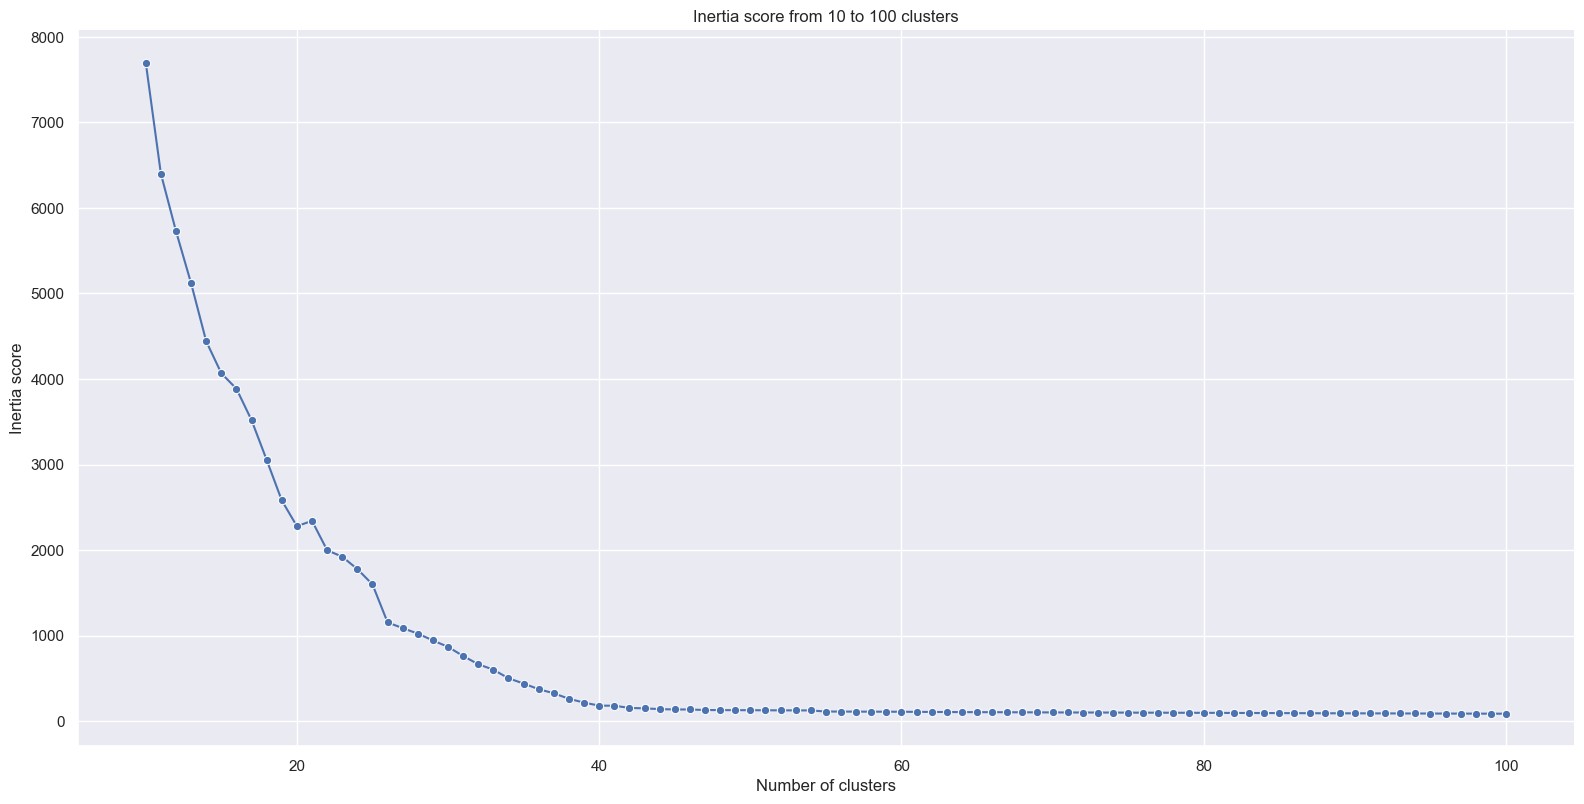

In [304]:
# Set the Seaborn theme to darkgrid
sns.set_theme(style='darkgrid')
%matplotlib inline
(
# Create a line plot of the inertia scores
sns.relplot(y = inertia_list,
            x = range(10, max_k + 1),
            kind = 'line',
            marker = 'o',
            height = 8,
            aspect = 2)
# Set the title of the plot
.set(title=f"Inertia score from 10 to {max_k} clusters")
# Set the axis labels
.set_axis_labels("Number of clusters", "Inertia score")
);()

In [305]:
max_k = 100
sil_list = []
for j in range(10, max_k + 1):
  s_kmeans = KMeans(n_clusters=j,
             n_init = "auto",
             random_state=seed)
  s_kmeans.fit(my_t)
  labels = s_kmeans.labels_
  score = silhouette_score(my_t, labels)
  sil_list.append(score)

/Users/samaardi/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


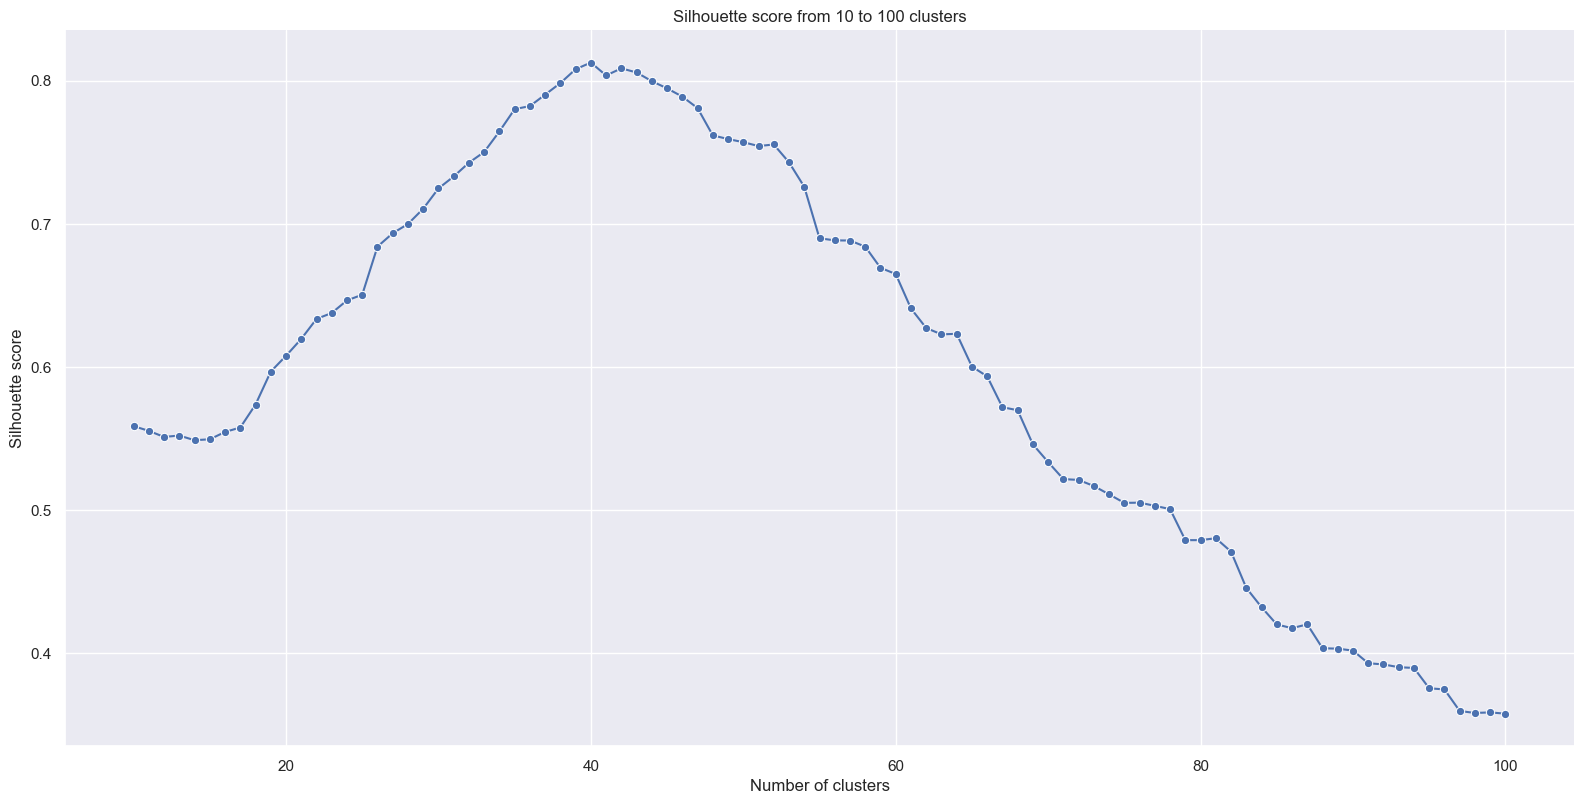

In [306]:
(
sns.relplot(y = sil_list,
            x = range(10, max_k + 1),
            kind = 'line',
            marker = 'o',
            height = 8,
            aspect = 2)
.set(title=f"Silhouette score from 10 to {max_k } clusters")
.set_axis_labels("Number of clusters", "Silhouette score")
);

In [262]:
my_pca = PCA()
pca_variance_df = my_pca.fit(df_filtered)
explained_blobs_variance_array = my_pca.explained_variance_ratio_
explained_blobs_variance_array

array([0.57072432, 0.28931315, 0.06120499, 0.04620093, 0.01766106,
       0.01489556])

/Users/samaardi/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


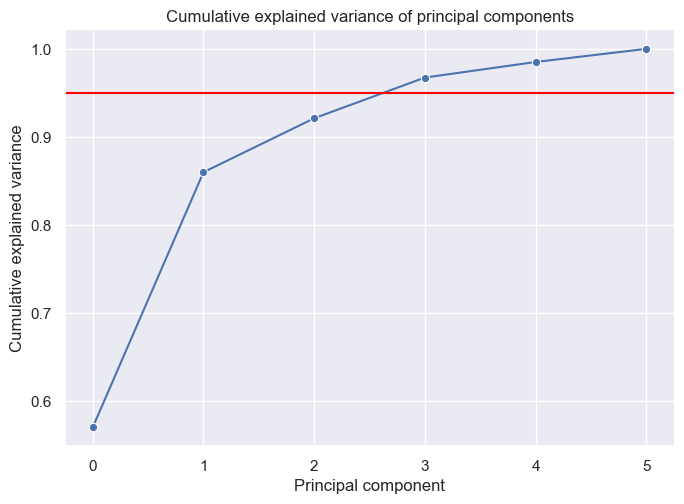

In [263]:
(
  # Create a cumulative explained variance plot
  sns.relplot(
      kind = "line",  # Create a line plot
      x = np.arange(len(explained_blobs_variance_array)),  # Set the x-axis to be the principal component index
      y = np.cumsum(explained_blobs_variance_array),  # Set the y-axis to be the cumulative explained variance
      marker = "o",  # Use a circle marker for the data points
      aspect = 1.4,  # Set the aspect ratio of the plot to be 1.4
  )
  # Set the title of the plot
  .set(title = "Cumulative explained variance of principal components")
  # Set the axis labels
  .set_axis_labels("Principal component", "Cumulative explained variance")
);

# Add a horizontal red line at 0.95 on the y axis
plt.axhline(y = 0.95,
            color = 'red');

In [264]:
# Calculate the cumulative sum
cumulative_sum = np.cumsum(explained_blobs_variance_array)

# Find the index where the cumulative sum reaches 0.95
index = np.searchsorted(cumulative_sum, 0.95)

# Print the number of components required to reach 0.95 variance
print(index + 1)

4


In [267]:
my_pca = PCA(n_components=4)
my_t = my_pca.fit_transform(df_filtered)
my_t

,,pca0,pca1,pca2,pca3
name,artist,,,,
Se Eu Quiser Falar Com Deus,Gilberto Gil,0.517147,0.078617,0.828459,-0.021070
Saudade De Bahia,Antônio Carlos Jobim,0.031652,0.364625,-0.067785,0.032777
"Canta Canta, Minha Gente",Martinho Da Vila,-0.049687,0.586627,-0.041842,-0.118727
Mulher Eu Sei,Chico César,0.779008,0.361657,0.251758,-0.009553
Rosa Morena,Kurt Elling,0.810276,0.238812,-0.035169,0.063772
...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",Pyotr Ilyich Tchaikovsky,0.981326,-0.286168,-0.066282,-0.079999
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",Tristan Murail,0.921251,-0.333734,-0.085344,-0.106012
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",Arnold Schoenberg,1.139691,-0.376196,-0.069465,-0.140573


In [295]:
df_filtered.drop(columns=['cluster'], inplace=True)

KeyError: "['cluster'] not found in axis"

<Axes: xlabel='pca0', ylabel='pca1'>

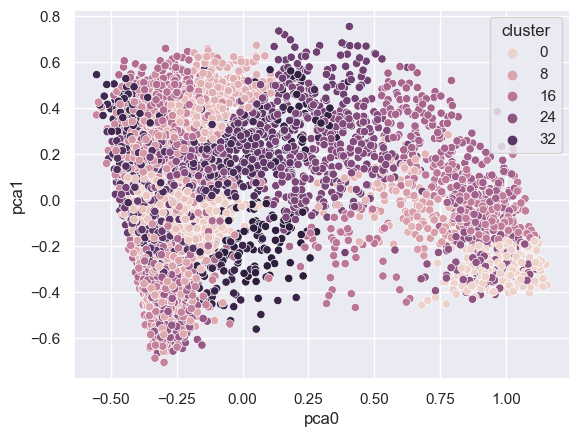

In [301]:
kmean_best_pca = KMeans(n_clusters=40,
      n_init='auto',
      random_state=seed)
fitted_best_kmean = kmean_best_pca.fit(my_t)
fitted_best_kmean.labels_
my_t['cluster'] = fitted_best_kmean.labels_
sns.scatterplot(data=my_t,x=my_t['pca0'],y=my_t['pca1'], hue=my_t['cluster'])

In [307]:
df_filtered['cluster'] = fitted_best_kmean.labels_

/tmp/ipykernel_12190/2738563621.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['cluster'] = fitted_best_kmean.labels_


In [340]:
#sleeping
df_filtered.loc[df_filtered['cluster'] == 0, :].sample(20)

,,speechiness,liveness,tempo,time_signature,acoustic_loudness_energy,danceability_valence,cluster
name,artist,,,,,,,
Night,Ludovico Einaudi,0.040087,0.101317,0.292546,0.8,0.909929,-0.455358,0
Angle of List,Loscil,0.049564,0.096251,0.316599,0.8,0.959275,-0.563113,0
"Piano Sonata No. 14 (quasi una Fantasia) in C-Sharp Minor, Op. 27 No.2 ""Moonlight"": I. Adagio sostenuto",Ludwig van Beethoven,0.045861,0.129686,0.316398,0.8,1.032736,-0.509293,0
"Symphony No.1 in C minor, Op.68: 1. Un poco sostenuto - Allegro - Meno allegro",Johannes Brahms,0.038235,0.161094,0.482167,0.8,0.851843,-0.475394,0
A Tree & A River,Henry Smith,0.047277,0.096859,0.364139,0.8,0.896411,-0.545271,0
Sugar Land,Davide Locatelli,0.041285,0.129686,0.371279,0.8,0.783324,-0.400466,0
Flower Through Concrete,Chloe Flower,0.040414,0.106383,0.322739,0.8,0.823741,-0.424067,0
unother,Terekke,0.045969,0.093212,0.326627,0.8,0.952506,-0.493276,0
Introspection (Edit),Laraaji,0.035839,0.070821,0.372022,0.6,0.863146,-0.583855,0


In [276]:
#blues
df_filtered.loc[df_filtered['cluster'] == 12, :].sample(20)

,,speechiness,liveness,tempo,time_signature,acoustic_loudness_energy,danceability_valence,cluster
name,artist,,,,,,,
Weather With You,Crowded House,0.030392,0.216819,0.439189,0.8,0.003064,0.448972,12
You Can Get It If You Really Want,Jimmy Cliff,0.061874,0.077204,0.598925,0.8,0.022332,0.632162,12
Break Ya Neck,Busta Rhymes,0.263617,0.062209,0.387934,0.8,0.046939,0.434597,12
Juicy - 2005 Remaster,The Notorious B.I.G.,0.275599,0.181358,0.448914,0.8,0.027011,0.508123,12
No Diggity,Blackstreet,0.225490,0.134752,0.414332,0.8,0.015040,0.438443,12
Blue Suede Shoes,Carl Perkins,0.035185,0.156028,0.394836,0.8,0.105595,0.507131,12
Obsesión,Maluma,0.117647,0.094833,0.416085,0.8,0.112927,0.438788,12
Sin Pijama,Becky G,0.050545,0.105370,0.439338,0.8,-0.021817,0.480095,12
Jamming,Bob Marley & The Wailers,0.325708,0.131712,0.577929,0.8,0.036640,0.494754,12


In [277]:
#happy
df_filtered.loc[df_filtered['cluster'] == 33, :].sample(20)

,,speechiness,liveness,tempo,time_signature,acoustic_loudness_energy,danceability_valence,cluster
name,artist,,,,,,,
I'll Stand by You,Pretenders,0.033224,0.076393,0.625366,0.8,0.028584,-0.189602,33
Oats In The Water,Ben Howard,0.031481,0.190476,0.597547,0.8,0.096834,-0.374004,33
Easy,Commodores,0.034205,0.075279,0.617524,0.8,0.102300,-0.038580,33
"I Don’t Wanna Live Forever (Fifty Shades Darker) - From ""Fifty Shades Darker (Original Motion Picture Soundtrack)""",ZAYN,0.063725,0.329281,0.551301,0.8,-0.056719,-0.157869,33
Swang,Rae Sremmurd,0.063290,0.101317,0.654199,0.8,0.135621,-0.124858,33
"Love Me Like You Do - From ""Fifty Shades Of Grey""",Ellie Goulding,0.058932,0.128673,0.885943,0.8,-0.001162,-0.298540,33
Sonnentanz,Klangkarussell,0.168845,0.088349,0.560236,0.8,0.148042,-0.155919,33
"Circle of Life - From ""The Lion King""/Soundtrack Version",Elton John,0.036057,0.107396,0.750442,0.8,0.158550,-0.379315,33
Waddlin Around,The King Khan & BBQ Show,0.060893,0.268490,0.694818,0.8,0.121004,-0.198755,33


In [343]:
#spanish bar jazz
df_filtered.loc[df_filtered['cluster'] == 26, :].sample(20)

,,speechiness,liveness,tempo,time_signature,acoustic_loudness_energy,danceability_valence,cluster
name,artist,,,,,,,
"All of You (feat. John Coltrane, Red Garland, Paul Chambers & Philly Joe Jones)",Miles Davis,0.046187,0.186424,0.385228,0.8,0.346984,0.186514,26
Let's Stay Together,Al Green,0.056863,0.054914,0.476588,0.8,0.377451,0.201248,26
There's No Business Like Show Business,Sonny Rollins,0.040414,0.106383,0.420851,0.8,0.456001,0.082594,26
Sampa,Caetano Veloso,0.072113,0.147923,0.534240,0.8,0.430311,0.264664,26
Felicia and Bianca,Toots Thielemans,0.051416,0.103343,0.493846,0.8,0.565040,0.191314,26
Just A Gigolo - Remastered,Louis Prima,0.102941,0.057244,0.585013,0.8,0.398553,0.235142,26
Serenade To A Soul Sister - Remastered,Horace Silver,0.033224,0.091489,0.675490,0.6,0.411999,0.107597,26
Bedingungslos (Single Mix),Kate & Ben,0.036601,0.094428,0.588411,0.8,0.561615,0.026470,26
Blueberry Hill,Fats Domino,0.029521,0.158055,0.623118,0.6,0.445153,0.304731,26


In [341]:
# summer festival
df_filtered.loc[df_filtered['cluster'] == 21, :].sample(20)

,,speechiness,liveness,tempo,time_signature,acoustic_loudness_energy,danceability_valence,cluster
name,artist,,,,,,,
River Flows in You,Yiruma,0.058932,0.091185,0.680887,0.8,0.775773,-0.215132,21
Shape of You,Henry Smith,0.043682,0.113475,0.719090,0.8,0.888524,-0.135661,21
"Bang Bang (My Baby Shot Me Down) - From ""Kill Bill""",Thibault Cauvin,0.051634,0.097467,0.569840,0.2,0.760712,-0.243986,21
Strange Meadow Lark,The Dave Brubeck Quartet,0.046078,0.281662,0.586308,0.8,0.853027,-0.254935,21
Acabou Chorare,Sílvia Pérez Cruz,0.059150,0.110436,0.470410,0.8,0.852332,-0.076207,21
You Don't Know What Love Is,Dinah Washington,0.055882,0.091793,0.644105,0.8,0.871090,-0.106175,21
Get Out Of Town,Caetano Veloso,0.066885,0.105370,0.505019,0.8,0.842922,-0.149528,21
Dancing In The Moonlight,Elin Porsinger,0.067538,0.102330,0.513954,0.8,0.955616,-0.026694,21
"Partita No. 6 in E Minor, BWV 830: IV. Air",Johann Sebastian Bach,0.043791,0.130699,0.676518,0.8,0.953675,-0.005730,21


In [281]:
# American movies 🍿 / country music
df_filtered.loc[df_filtered['cluster'] == 39, :].sample(20)

,,speechiness,liveness,tempo,time_signature,acoustic_loudness_energy,danceability_valence,cluster
name,artist,,,,,,,
It's Only Make Believe - Single Version,Conway Twitty,0.041830,0.128673,0.588897,0.8,0.531570,-0.062450,39
Mr. Tambourine Man,Bob Dylan,0.073638,0.383992,0.829548,0.8,0.615690,0.043129,39
I Have Nothing - Film Version,Whitney Houston,0.037255,0.086322,0.714351,0.6,0.487649,-0.239581,39
The Rite of Spring: Part Two: The Sacrifice: Sacrificial Dance (The Chosen One),Igor Stravinsky,0.113290,0.156028,0.633964,0.8,0.584797,-0.092831,39
Alone,Heart,0.038780,0.097163,0.818206,0.8,0.404001,-0.282381,39
Top Of The World,Carpenters,0.041939,0.100405,0.861260,0.8,0.600563,0.127025,39
"Lay, Lady, Lay",Bob Dylan,0.049455,0.132725,0.727819,0.8,0.375419,-0.023902,39
Sonho Meu,Dona Ivone Lara,0.044444,0.124620,0.691925,0.8,0.396457,0.053157,39
Ponta de Areia,Wayne Shorter,0.035403,0.077913,0.825609,0.8,0.672729,-0.279053,39


In [285]:
# Rock bar
df_filtered.loc[df_filtered['cluster'] == 2, :].sample(20)

,,speechiness,liveness,tempo,time_signature,acoustic_loudness_energy,danceability_valence,cluster
name,artist,,,,,,,
Bleeding,Desultory,0.113290,0.339412,0.734474,0.8,-0.386074,-0.356304,2
Bleeding Shrines of Stone,Liers In Wait,0.128540,0.207700,0.643287,0.2,-0.428732,-0.472145,2
Defiling the Gates of Ishtar,Nile,0.103813,0.500507,0.574003,0.8,-0.390607,-0.407135,2
Icons of Evil,Vital Remains,0.137255,0.376900,0.832469,0.8,-0.427443,-0.581439,2
Cthulhu,Therion,0.046078,0.352584,0.838768,0.8,-0.337100,-0.295696,2
Labyrinth,Sacrificium,0.076906,0.459980,0.607664,0.8,-0.369225,-0.344548,2
I'm in Pain,Obituary,0.084423,0.249240,0.689733,0.8,-0.429424,-0.403764,2
Eclipse into Eternity,Oppressor,0.172113,0.300912,0.626870,0.8,-0.407191,-0.384326,2
Subconscious Release,Desecrator,0.067320,0.408308,0.728071,0.8,-0.352016,-0.411342,2


In [286]:
df_filtered.loc[df_filtered['cluster'] == 9, :].sample(20)

,,speechiness,liveness,tempo,time_signature,acoustic_loudness_energy,danceability_valence,cluster
name,artist,,,,,,,
We Are Your Friends - Justice Vs Simian,Justice,0.129630,0.180344,0.574761,0.8,-0.440246,0.115913,9
They Are the Children of the Underworld,Deicide,0.055991,0.085309,0.437647,0.6,-0.418513,0.053115,9
Andas En Mi Cabeza,Chino & Nacho,0.141612,0.112462,0.486537,0.8,-0.410381,0.190142,9
Head On,The Jesus and Mary Chain,0.035294,0.138804,0.649689,0.8,-0.383895,0.060618,9
Who Do You Love,The Chainsmokers,0.048693,0.221884,0.654348,0.8,-0.343035,-0.006905,9
Walk Away,Franz Ferdinand,0.037908,0.196555,0.579948,0.8,-0.239246,0.125310,9
The Black Dahlia,Lamb of God,0.113290,0.044883,0.422422,0.8,-0.417543,0.084940,9
You Can't Change Me,Don Diablo,0.059150,0.038095,0.578574,0.8,-0.187453,0.100884,9
Till The Sun Comes Up,Firebeatz,0.040305,0.192503,0.579097,0.8,-0.300513,0.065525,9


In [ ]:
final_pca = PCA(n_components=1)
final_trans = my_dv.fit_transform(df_5_scaled_without_inst_mode_key[['danceability', 'valence']])

In [108]:
df_5_scaled.nunique()

danceability         882
energy              1191
key                   12
loudness            4310
mode                   2
speechiness         1001
acousticness        2545
instrumentalness    2168
liveness            1128
valence             1267
tempo               4824
time_signature         5
dtype: int64

In [ ]:
df_5_scaled

In [74]:
pca_variance_df = my_pca.fit_transform(df_5_scaled)

In [75]:
pca_variance_df

,,pca0,pca1
name,artist,,
Se Eu Quiser Falar Com Deus,Gilberto Gil,-0.095853,0.757760
Saudade De Bahia,Antônio Carlos Jobim,-0.016274,-0.452885
"Canta Canta, Minha Gente",Martinho Da Vila,-0.125222,-0.504089
Mulher Eu Sei,Chico César,0.506225,-0.182971
Rosa Morena,Kurt Elling,0.543287,-0.130601
...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",Pyotr Ilyich Tchaikovsky,1.174325,0.114664
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",Tristan Murail,0.971897,0.069892
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",Arnold Schoenberg,1.399976,0.330040


<Axes: xlabel='pca0', ylabel='pca1'>

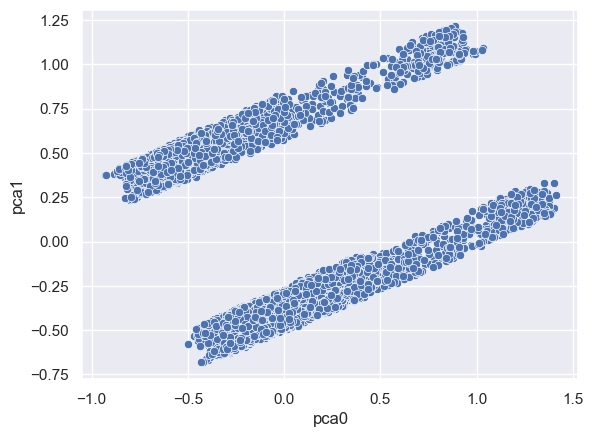

In [76]:
sns.scatterplot(data=pca_variance_df,x=pca_variance_df['pca0'],y=pca_variance_df['pca1'])

In [78]:
kmean_1 = KMeans(n_clusters=46,
      random_state=seed,
      n_init = "auto",)
kmean_one = kmean_1.fit_predict(pca_variance_df[["pca0","pca1"]])

In [79]:
pca_variance_df["class"]=kmean_one

In [80]:
pca_variance_df.head()

,,pca0,pca1,class
name,artist,,,
Se Eu Quiser Falar Com Deus,Gilberto Gil,-0.095853,0.757760,35
Saudade De Bahia,Antônio Carlos Jobim,-0.016274,-0.452885,28
"Canta Canta, Minha Gente",Martinho Da Vila,-0.125222,-0.504089,1
Mulher Eu Sei,Chico César,0.506225,-0.182971,36
Rosa Morena,Kurt Elling,0.543287,-0.130601,23


<Axes: xlabel='pca0', ylabel='pca1'>

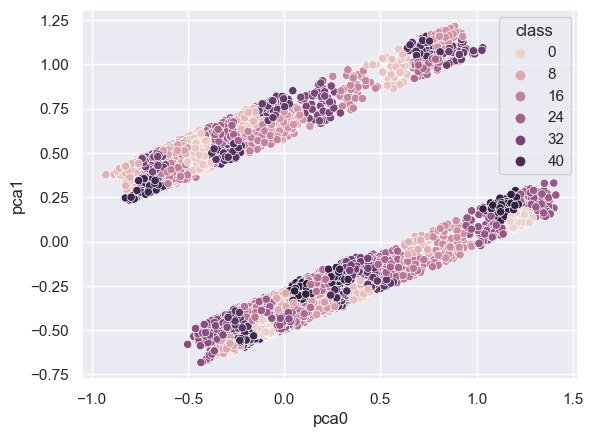

In [81]:
sns.scatterplot(data=pca_variance_df,x=pca_variance_df['pca0'],y=pca_variance_df['pca1'], hue=pca_variance_df['class'])

In [339]:
df_filtered

,,speechiness,liveness,tempo,time_signature,acoustic_loudness_energy,danceability_valence,cluster
name,artist,,,,,,,
Se Eu Quiser Falar Com Deus,Gilberto Gil,0.076797,0.987842,0.515800,0.8,0.564666,-0.023528,28
Saudade De Bahia,Antônio Carlos Jobim,0.037691,0.108409,0.584322,0.8,0.106960,0.345892,31
"Canta Canta, Minha Gente",Martinho Da Vila,0.377996,0.125633,0.437862,0.8,0.085583,0.586381,6
Mulher Eu Sei,Chico César,0.051307,0.391084,0.499098,0.8,0.849591,0.184377,20
Rosa Morena,Kurt Elling,0.041394,0.105370,0.565171,0.8,0.841602,0.051264,20
...,...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",Pyotr Ilyich Tchaikovsky,0.051525,0.084296,0.410795,0.8,0.882772,-0.497485,0
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",Tristan Murail,0.048148,0.070314,0.388495,0.8,0.810967,-0.530654,0
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",Arnold Schoenberg,0.047277,0.078217,0.334469,0.6,1.007201,-0.609269,0


In [311]:
df_spotify = pd.read_csv('/Users/samaardi/Desktop/WBS-Data Science Bootcamp/unsupervised machine learning/3_spotify_5000_songs.csv')

In [314]:
df_spotify.columns = df_spotify.columns.str.strip()

In [334]:
id_df = df_spotify[['id', 'speechiness']]
id_df

,id,speechiness
0,1n7JnwviZ7zf0LR1tcGFq7,0.0705
1,5QGM1U0eCYrQuwSJwTm5Zq,0.0346
2,0NLIFSZxPzQhCwnkn5PJYs,0.3470
3,3mXqOdlLE1k67WsAxryPFs,0.0471
4,7bSzjzjTkWT2CkIPPdp0eA,0.0380
...,...,...
5230,1aEhYlZtypmipA06SDJ4U3,0.0473
5231,1Gfqe7TAKklmuZf6hxsH6h,0.0442
5232,2XNwnFrdMDpismp0VUZ7cU,0.0434
5233,7ucDwgMtE3YJtEfTbuRhy0,0.0419


In [337]:
pd.merge(id_df, df_filtered, how='inner', on='speechiness')

,id,speechiness,liveness,tempo,time_signature,acoustic_loudness_energy,danceability_valence,cluster
0,4NSW0Km5ZG60L8FthUebPJ,0.05,0.058764,0.673013,0.8,-0.421383,0.254633,10
1,4NSW0Km5ZG60L8FthUebPJ,0.05,0.144883,0.534235,0.8,-0.395904,0.501450,36
2,4NSW0Km5ZG60L8FthUebPJ,0.05,0.442756,0.615519,0.8,0.235955,0.233278,38
3,4NSW0Km5ZG60L8FthUebPJ,0.05,0.142857,0.695523,0.8,0.055872,0.154757,34
4,4NSW0Km5ZG60L8FthUebPJ,0.05,0.186424,0.560797,0.8,-0.312075,0.093609,2
...,...,...,...,...,...,...,...,...
72,1CcS1yrulOFPXYk7NVKAm2,0.05,0.130699,0.653334,0.8,0.851302,-0.266093,21
73,1CcS1yrulOFPXYk7NVKAm2,0.05,0.103343,0.356947,0.8,1.014037,-0.245929,15
74,1CcS1yrulOFPXYk7NVKAm2,0.05,0.097366,0.565386,0.8,-0.292563,0.269216,10
75,1CcS1yrulOFPXYk7NVKAm2,0.05,0.194529,0.454708,0.8,-0.434511,-0.276001,22


In [326]:
df_spotify['cluster'] = fitted_best_kmean.labels_

ValueError: Length of values (5234) does not match length of index (5235)

In [332]:
df_spotify_final = df_spotify.loc[~(df_spotify == 0).all(axis=1)]

In [333]:
df_spotify_final.shape

(5235, 18)

In [330]:
df_spotify.columns

Index(['Unnamed: 0', 'name', 'artist', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'type', 'duration_ms', 'time_signature',
       'id', 'html'],
      dtype='object')

In [331]:
df_spotify.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
df_spotify.drop(columns=['type'], inplace=True)

In [338]:
df_spotify.set_index('name', 'artist')

,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,duration_ms,time_signature,id,html
0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.6580,0.25900,11,-13.141,0,0.0705,0.694,0.000059,0.9750,0.3060,110.376,,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...
1,Saudade De Bahia ...,Antônio Carlos Jobim,0.7420,0.39900,2,-12.646,1,0.0346,0.217,0.000002,0.1070,0.6930,125.039,,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...
2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.8510,0.73000,2,-11.048,1,0.3470,0.453,0.000063,0.1240,0.9050,93.698,,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...
3,Mulher Eu Sei ...,Chico César,0.7050,0.05020,4,-18.115,1,0.0471,0.879,0.000041,0.3860,0.5240,106.802,,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...
4,Rosa Morena ...,Kurt Elling,0.6510,0.11900,6,-19.807,1,0.0380,0.916,0.000343,0.1040,0.4020,120.941,,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5230,"1812 Festival Overture, Op. 49: 1812 Overture,...",Pyotr Ilyich Tchaikovsky,0.2020,0.06940,3,-23.390,1,0.0473,0.917,0.715000,0.0832,0.0655,87.906,,995000,4,1aEhYlZtypmipA06SDJ4U3,https://open.spotify.com/track/1aEhYlZtypmipA0...
5231,"Winter Fragments pour ensemble instrumental, s...",Tristan Murail,0.1880,0.10100,6,-21.873,1,0.0442,0.855,0.426000,0.0694,0.0355,83.134,,855000,4,1Gfqe7TAKklmuZf6hxsH6h,https://open.spotify.com/track/1Gfqe7TAKklmuZf...
5232,"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3...",Arnold Schoenberg,0.0596,0.00093,9,-42.959,1,0.0434,0.951,0.969000,0.0772,0.0344,71.573,,238187,3,2XNwnFrdMDpismp0VUZ7cU,https://open.spotify.com/track/2XNwnFrdMDpismp...
5233,"Serenade For Strings In E, Op.22, B. 52: 1. Mo...",Antonín Dvořák,0.1330,0.02080,4,-29.443,1,0.0419,0.883,0.505000,0.1110,0.0591,67.109,,314307,4,7ucDwgMtE3YJtEfTbuRhy0,https://open.spotify.com/track/7ucDwgMtE3YJtEf...
